In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print('PyTorch version:', torch.__version__)

Using device: cpu
PyTorch version: 2.2.2


In [2]:
SUBSETS        = ['FD001', 'FD002', 'FD003', 'FD004']
USEFUL_SENSORS = ['s2','s3','s4','s7','s8','s9','s11',
                  's12','s13','s14','s15','s17','s20','s21']
WINDOW_SIZE    = 30
RUL_CAP        = 125

X_train = np.load('../data/X_train_multi.npy')
y_train = np.load('../data/y_train_multi.npy')

test_data = {}
for subset in SUBSETS:
    X = np.load(f'../data/X_test_{subset}.npy')
    y = np.load(f'../data/y_test_{subset}.npy')
    test_data[subset] = (X, y)

print(f'X_train : {X_train.shape}')
print(f'y_train : {y_train.shape}')
print()
for subset, (X, y) in test_data.items():
    print(f'{subset} — X: {X.shape}, y: {y.shape}')

X_train : (139798, 30, 14)
y_train : (139798,)

FD001 — X: (100, 30, 14), y: (100,)
FD002 — X: (259, 30, 14), y: (259,)
FD003 — X: (100, 30, 14), y: (100,)
FD004 — X: (248, 30, 14), y: (248,)


In [3]:
BATCH_SIZE = 512

X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Convert all test sets to tensors
test_tensors = {}
for subset, (X, y) in test_data.items():
    test_tensors[subset] = (
        torch.FloatTensor(X).to(device),
        torch.FloatTensor(y).to(device)
    )

print(f'Batches per epoch : {len(train_loader)}')
print(f'Train samples     : {len(train_dataset)}')

Batches per epoch : 274
Train samples     : 139798


In [5]:
class RULPredictor(nn.Module):
    def __init__(self, input_size=14, hidden_size=256, num_layers=3, dropout=0.3):
        super(RULPredictor, self).__init__()

        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0
        )
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_step   = lstm_out[:, -1, :]   # take final timestep only
        return self.regressor(last_step).squeeze(1)

model     = RULPredictor().to(device)
criterion = nn.MSELoss()
optimiser = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser, mode='min', factor=0.5, patience=15
)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable parameters: {n_params:,}')

RULPredictor(
  (lstm): LSTM(14, 256, num_layers=3, batch_first=True, dropout=0.3)
  (regressor): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)

Trainable parameters: 1,364,225


In [6]:
class EarlyStopping:
    def __init__(self, patience=40, min_delta=0.1):
        self.patience    = patience
        self.min_delta   = min_delta
        self.counter     = 0
        self.best_loss   = float('inf')
        self.should_stop = False

    def check(self, loss):
        if loss < self.best_loss - self.min_delta:
            self.best_loss = loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

EPOCHS     = 200
train_losses  = []
test_losses   = []
best_rmse     = float('inf')
early_stop    = EarlyStopping(patience=40, min_delta=0.1)

X_eval, y_eval = test_tensors['FD001']

for epoch in range(EPOCHS):

    # --- train ---
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        optimiser.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimiser.step()
        batch_losses.append(loss.item())

    train_rmse = np.sqrt(np.mean(batch_losses))

    # --- eval on FD001 ---
    model.eval()
    with torch.no_grad():
        preds_eval = model(X_eval)
        test_rmse  = np.sqrt(criterion(preds_eval, y_eval).item())

    train_losses.append(train_rmse)
    test_losses.append(test_rmse)
    scheduler.step(test_rmse)

    # Save best weights
    if test_rmse < best_rmse:
        best_rmse = test_rmse
        torch.save(model.state_dict(), '../models/lstm_multi_best.pt')

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:>4} | Train RMSE: {train_rmse:.2f} | '
              f'Test RMSE: {test_rmse:.2f} | Best: {best_rmse:.2f}')

    early_stop.check(test_rmse)
    if early_stop.should_stop:
        print(f'\nEarly stopping at epoch {epoch+1}')
        break

print(f'\nBest FD001 RMSE during training: {best_rmse:.2f}')

Epoch   10 | Train RMSE: 18.68 | Test RMSE: 15.12 | Best: 15.12
Epoch   20 | Train RMSE: 16.68 | Test RMSE: 13.51 | Best: 13.36
Epoch   30 | Train RMSE: 16.20 | Test RMSE: 13.97 | Best: 12.61
Epoch   40 | Train RMSE: 15.80 | Test RMSE: 12.48 | Best: 12.21
Epoch   50 | Train RMSE: 15.45 | Test RMSE: 13.07 | Best: 12.19
Epoch   60 | Train RMSE: 15.08 | Test RMSE: 12.61 | Best: 11.98
Epoch   70 | Train RMSE: 14.57 | Test RMSE: 12.78 | Best: 11.79
Epoch   80 | Train RMSE: 13.66 | Test RMSE: 13.64 | Best: 11.79
Epoch   90 | Train RMSE: 12.93 | Test RMSE: 13.53 | Best: 11.79
Epoch  100 | Train RMSE: 12.16 | Test RMSE: 13.50 | Best: 11.79

Early stopping at epoch 101

Best FD001 RMSE during training: 11.79


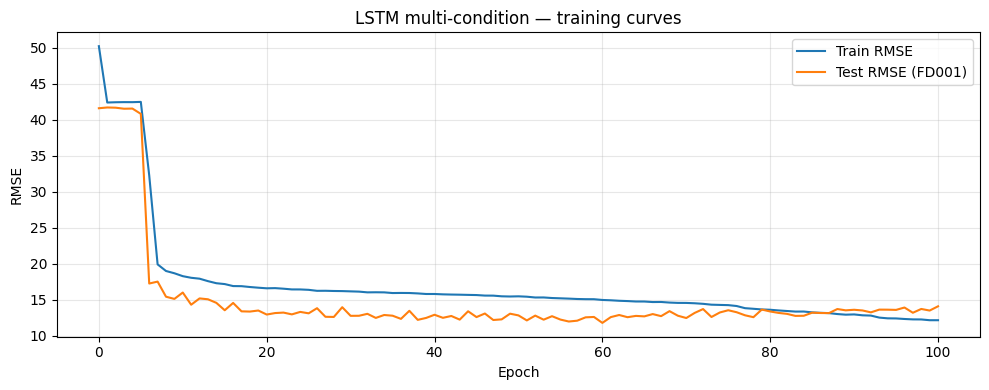

Final epoch    : 101
Best test RMSE : 11.79


In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train RMSE')
ax.plot(test_losses,  label='Test RMSE (FD001)')
ax.set_xlabel('Epoch')
ax.set_ylabel('RMSE')
ax.set_title('LSTM multi-condition — training curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Final epoch    : {len(train_losses)}')
print(f'Best test RMSE : {best_rmse:.2f}')

In [8]:
# Load best weights
model.load_state_dict(torch.load('../models/lstm_multi_best.pt'))
model.eval()

results = {}

with torch.no_grad():
    for subset in SUBSETS:
        X_t, y_t = test_tensors[subset]
        y_pred    = model(X_t).cpu().numpy()
        y_true    = y_t.cpu().numpy()
        rmse      = np.sqrt(mean_squared_error(y_true, y_pred))
        results[subset] = {'y_true': y_true, 'y_pred': y_pred, 'rmse': rmse}
        print(f'{subset} RMSE: {rmse:.2f}')

all_true = np.concatenate([results[s]['y_true'] for s in SUBSETS])
all_pred = np.concatenate([results[s]['y_pred'] for s in SUBSETS])
combined = np.sqrt(mean_squared_error(all_true, all_pred))
print(f'\nCombined RMSE: {combined:.2f}')

FD001 RMSE: 11.79
FD002 RMSE: 18.19
FD003 RMSE: 13.10
FD004 RMSE: 22.14

Combined RMSE: 18.36


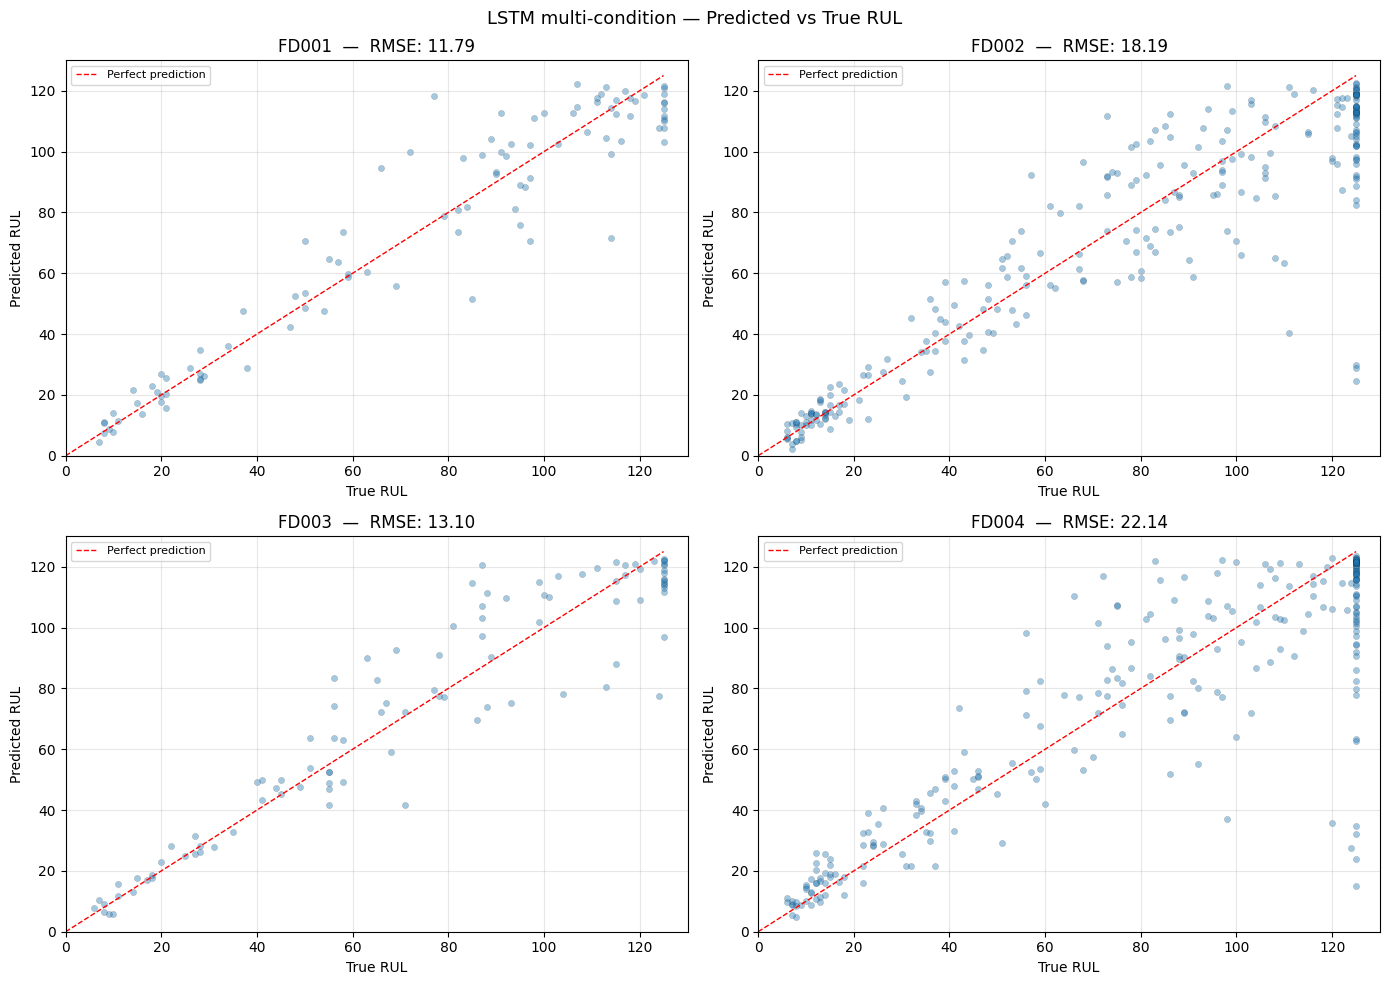

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, subset in zip(axes, SUBSETS):
    y_true = results[subset]['y_true']
    y_pred = results[subset]['y_pred']
    rmse   = results[subset]['rmse']

    ax.scatter(y_true, y_pred, alpha=0.4, edgecolors='k', linewidth=0.2, s=20)
    ax.plot([0, 125], [0, 125], 'r--', linewidth=1, label='Perfect prediction')
    ax.set_xlabel('True RUL')
    ax.set_ylabel('Predicted RUL')
    ax.set_title(f'{subset}  —  RMSE: {rmse:.2f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 130)
    ax.set_ylim(0, 130)

plt.suptitle('LSTM multi-condition — Predicted vs True RUL', fontsize=13)
plt.tight_layout()
plt.show()

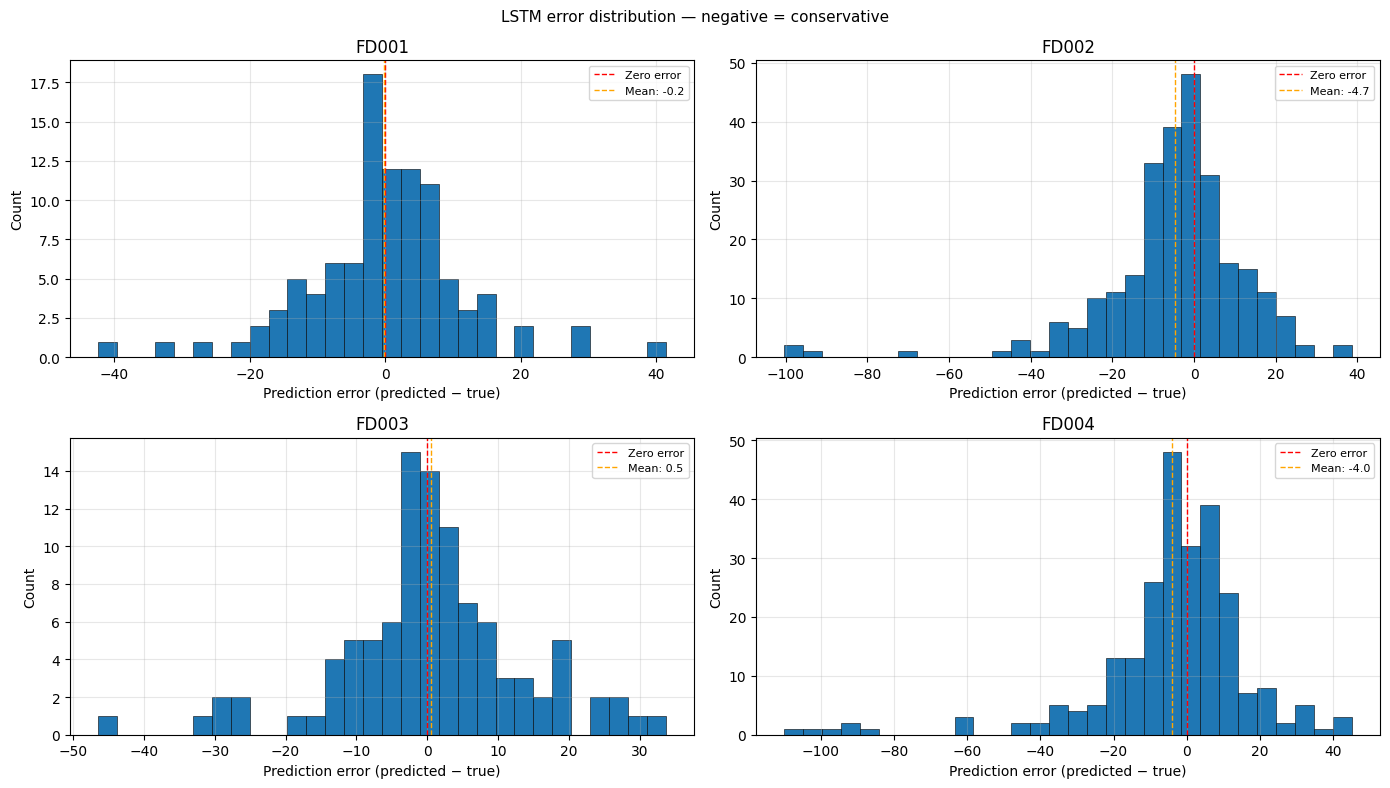

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, subset in zip(axes, SUBSETS):
    errors = results[subset]['y_pred'] - results[subset]['y_true']
    ax.hist(errors, bins=30, edgecolor='black', linewidth=0.4)
    ax.axvline(0,             color='red',    linestyle='--', linewidth=1, label='Zero error')
    ax.axvline(errors.mean(), color='orange', linestyle='--', linewidth=1,
               label=f'Mean: {errors.mean():.1f}')
    ax.set_title(subset)
    ax.set_xlabel('Prediction error (predicted − true)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('LSTM error distribution — negative = conservative', fontsize=11)
plt.tight_layout()
plt.show()

In [11]:
xgb_results = {'FD001': 13.86, 'FD002': 16.95, 'FD003': 15.30, 'FD004': 23.23}

print('='*60)
print(f'  {"Model":<40} {"RMSE":>8}')
print('-'*60)
print(f'  {"XGBoost — FD001 only":<40} {"14.26":>8}')
print(f'  {"LSTM v2 — FD001 only":<40} {"14.63":>8}')
print('-'*60)
for subset in SUBSETS:
    xgb  = xgb_results[subset]
    lstm = results[subset]['rmse']
    diff = xgb - lstm
    arrow = '↑ LSTM better' if diff > 0 else '↓ XGB better'
    print(f'  {"XGBoost multi — " + subset:<40} {xgb:>8.2f}')
    print(f'  {"LSTM multi    — " + subset:<40} {lstm:>8.2f}  {arrow} ({abs(diff):.2f})')
    print()
print('='*60)

  Model                                        RMSE
------------------------------------------------------------
  XGBoost — FD001 only                        14.26
  LSTM v2 — FD001 only                        14.63
------------------------------------------------------------
  XGBoost multi — FD001                       13.86
  LSTM multi    — FD001                       11.79  ↑ LSTM better (2.07)

  XGBoost multi — FD002                       16.95
  LSTM multi    — FD002                       18.19  ↓ XGB better (1.24)

  XGBoost multi — FD003                       15.30
  LSTM multi    — FD003                       13.10  ↑ LSTM better (2.20)

  XGBoost multi — FD004                       23.23
  LSTM multi    — FD004                       22.14  ↑ LSTM better (1.09)

